# **Methods Training - Những phương pháp huấn luyện mô hình**

Do bài toán dự đoán doanh thu đang có nhiều biến động và nhiễu, khiến cho việc huấn luyện các mô hình với các phương pháp thông thường đều rất khó có được kết quả tốt. Vì vậy, trong notebooks này chúng tôi sẽ đưa ra một vài phương pháp chính của chúng tôi cũng như thử nghiệm chúng để cải thiện được cho các mô hình.

Cụ thể:
- Đưa ra và kiểm thử những quy luật chung
- Liệt kê một vài phương pháp khả thi và kiểm chứng
- Chuẩn bị cho hướng đi tiếp theo

**Mục tiêu**: Tìm ra được phương pháp huấn luyện mô hình tốt nhất

**Mục lục**:

1. 
2. 
3. 
4. 

## 1. Thiết lập và cài đặt

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed, get_connection
from src.save_data import save_to_processed

In [46]:
conn = get_connection()

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


In [47]:
sales = conn.execute('SELECT * FROM sales').df()
sales.tail()

,date,revenue,cogs
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


In [48]:
pred = conn.execute('SELECT * FROM sales_test').df()
pred.head()

,date,revenue,cogs
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


In [49]:
print(f"Train Period: {sales['date'].min().date()} to {sales['date'].max().date()}")
print(f"Test Period : {pred['date'].min().date()} to {pred['date'].max().date()}")

Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01


## 2. Xây dựng mô hình cơ sở

In [50]:
train = sales.copy()
train["is_test"] = 0
test_df = pred[["date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True)
df.tail()

,date,revenue,cogs,is_test
4376,2024-06-27,NaN,NaN,1
4377,2024-06-28,NaN,NaN,1
4378,2024-06-29,NaN,NaN,1
4379,2024-06-30,NaN,NaN,1
4380,2024-07-01,NaN,NaN,1


## 3. Dự đoán trực tiếp

Đây là phương pháp dự đoán tương lai truyền thống, chúng tôi sẽ xây dựng bộ dữ liệu với toàn bộ features có mật thiết tới `revenue`. Ưu điểm là tốn ít tài nguyên và nhanh chóng, nhược điểm là không thể nắm được hoàn toàn 100% ngu cầu của khách hàng. Lý do là bởi vì khi đến những ngày có giảm giá, `revenue` chưa hề thể hiện được khoảng thời gian đó doanh thu tăng mạnh cũng là do chính những mã giảm giá đã có thể cắt bớt đi doanh thu. Điều này khiến cho việc mô hình không thể dự đoán chính xác

## 4. Dự đoán gián tiếp
Trong phần này, chúng tôi sẽ kiểm tra toàn bộ đặc trưng của tập dữ liệu có mật thiết cao tới `revenue`. Cụ thể, chúng tôi sẽ xác định những yếu tố nào đang làm ảnh hưởng tới `revenue` cao nhất. Từ đó, chúng tôi sẽ xây dựng mô hình để dự đoán những yếu tố đó rồi sử dụng dữ liệu dự đoán để tính ra kết quả cuối cùng. Hiện tại sau khi khám phá thì có những đặc trưng sau có mức tương quan cực cao tới `revenue`:
- `unique_customer`: Tổng số khách hàng trong một ngày
- `total_order`: Tổng số đơn hàng trong một ngày
- `total_product`: Tổng số sản phẩm bán được trong một ngày

In [51]:
orders = conn.execute('SELECT * FROM orders').df()
orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [52]:
order_items = conn.execute('SELECT * FROM order_items').df()
order_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,None,None
1,2,609,7,10166.25,0.0,None,None
2,3,396,3,11220.33,0.0,None,None
3,4,635,5,10639.25,0.0,None,None
4,6,1935,1,1597.84,0.0,None,None


In [53]:
# 2. Merge hai bảng dựa trên order_id
# Chúng ta dùng 'inner' để đảm bảo chỉ lấy những đơn hàng có chi tiết sản phẩm
df_merged = pd.merge(orders, order_items, on='order_id', how='inner')

# 4. Tổng hợp dữ liệu theo Ngày (Daily Aggregation)
# Đây là bước quan trọng để đưa dữ liệu về dạng Time-series
df_daily_revenue = df_merged.groupby('order_date').agg(
    order_count=('order_id', 'nunique'),        # Số lượng đơn hàng trong ngày
    unique_customers=('customer_id', 'nunique'), # Số lượng khách hàng trong ngày
    total_quantity=('quantity', 'sum')          # Tổng số lượng sản phẩm bán ra
).reset_index()

# 5. Sắp xếp theo thứ tự thời gian
df_daily_revenue = df_daily_revenue.sort_values('order_date')

print("Dữ liệu sau khi merge và tổng hợp theo ngày:")
df_daily_revenue.head()

Dữ liệu sau khi merge và tổng hợp theo ngày:


,order_date,order_count,unique_customers,total_quantity
0,2012-07-04,162,161,777
1,2012-07-05,97,97,428
2,2012-07-06,93,93,441
3,2012-07-07,73,73,364
4,2012-07-08,88,87,394


In [54]:
for col in ["order_count", "unique_customers", "total_quantity"]:
    print(f"Correlations {col} with Revenue: {df_daily_revenue[col].corr(df['revenue']):.2f}")

Correlations order_count with Revenue: 0.94
Correlations unique_customers with Revenue: 0.94
Correlations total_quantity with Revenue: 0.92


Trên đây là 3 biến với mực độ tương quan cao nhất với `revenue` bên cạnh `cogs`, vì vậy chúng tôi sẽ xây dựng thêm 3 cột nữa để sau đó có thể sử dụng để dự đoán những features đó trước khi dự đoán `revenue`

In [55]:
df = pd.merge(df, df_daily_revenue, left_on='date', right_on='order_date', how='left')
df = df.drop(columns=['order_date'])
df.head()

,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0


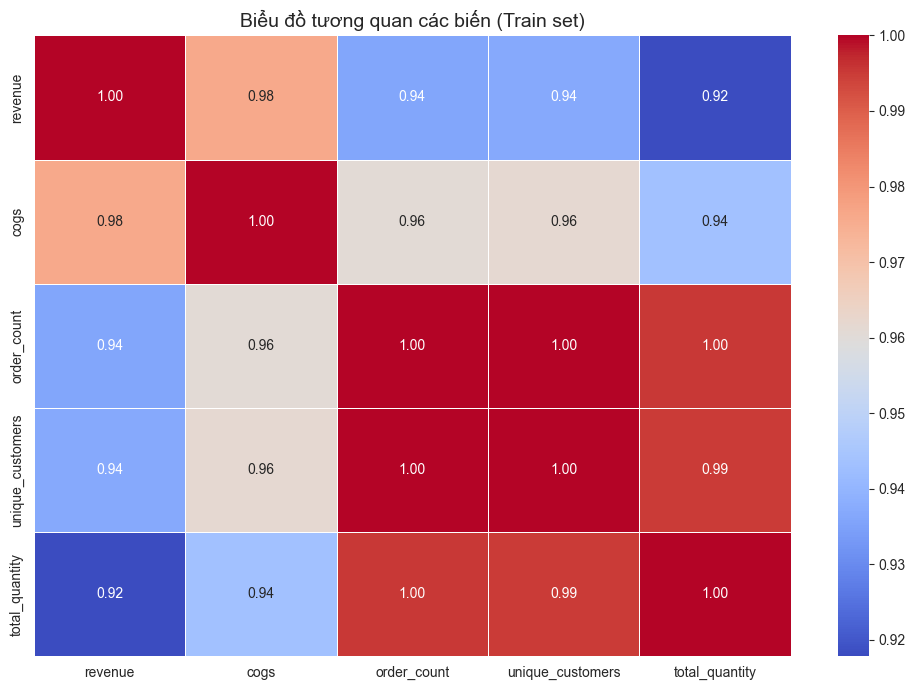

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc tập train
df_train = df[df['is_test'] == 0].copy()

# Chỉ lấy các cột số, bỏ is_test
cols = [
    'revenue',
    'cogs',
    'order_count',
    'unique_customers',
    'total_quantity'
]

# Tính ma trận tương quan
corr_matrix = df_train[cols].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Biểu đồ tương quan các biến (Train set)', fontsize=14)
plt.tight_layout()
plt.show()

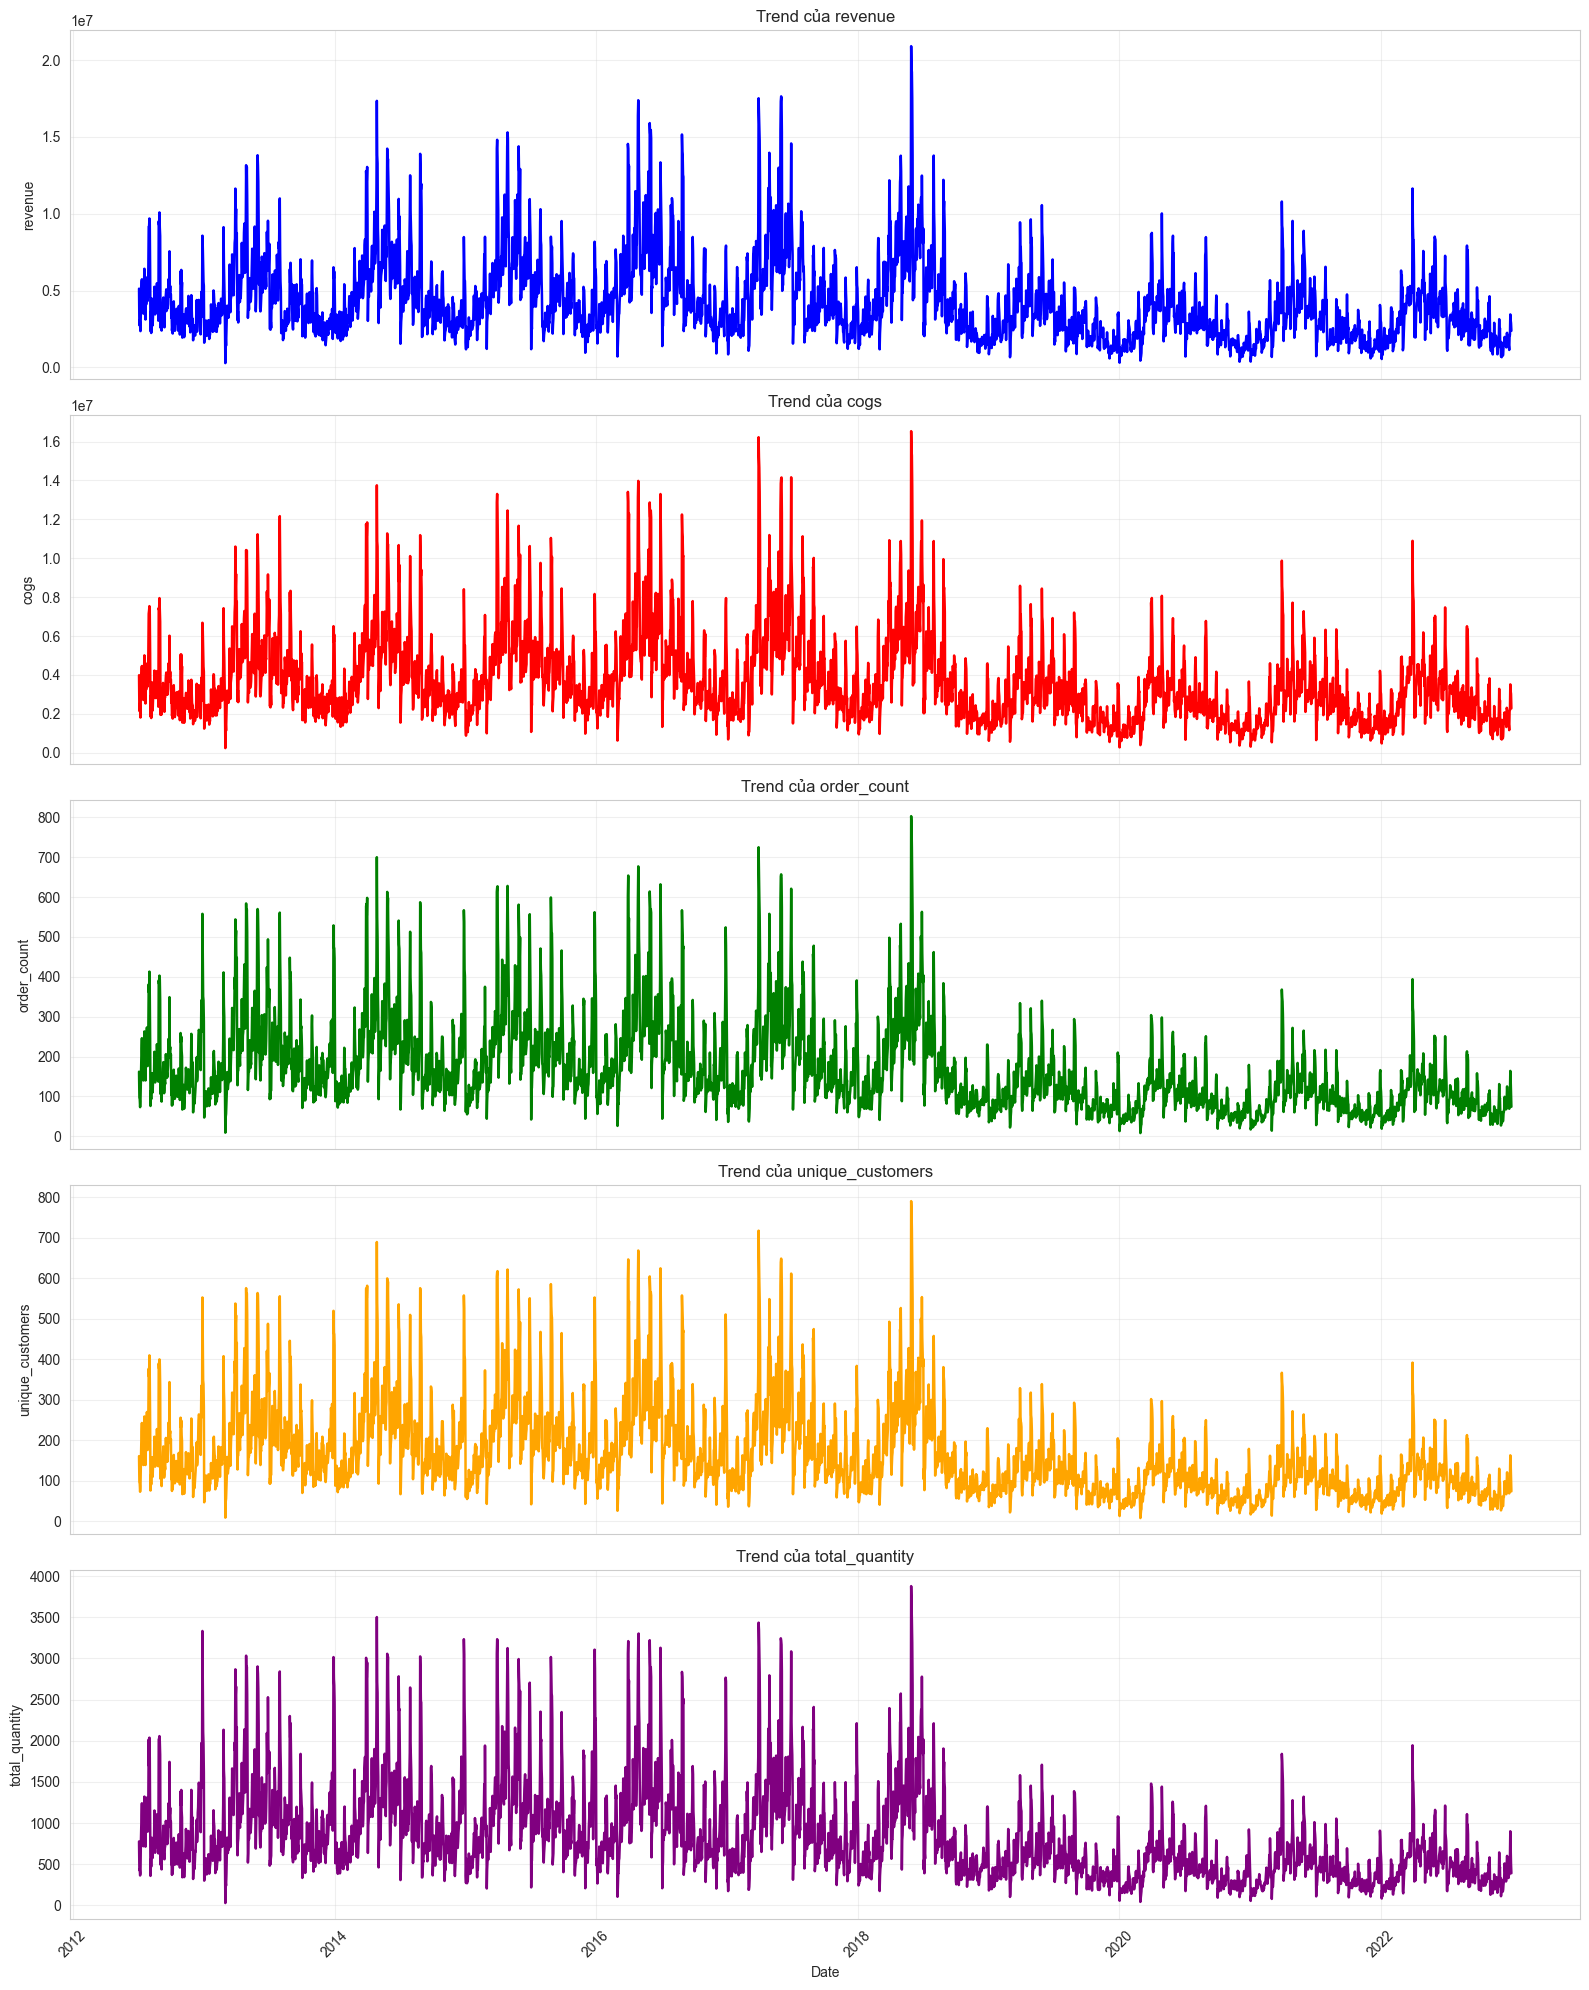

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc train set
df_train = df[df['is_test'] == 0].copy()

# Sắp xếp theo ngày
df_train = df_train.sort_values('date')

# Các cột cần vẽ
cols = [
    'revenue',
    'cogs',
    'order_count',
    'unique_customers',
    'total_quantity'
]

# Màu riêng
colors = ['blue', 'red', 'green', 'orange', 'purple']

# Tạo subplot (KHÔNG sharey vì scale quá lệch)
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(16, 20),
    sharex=True
)

sns.set_style("whitegrid")

for i, col in enumerate(cols):
    axes[i].plot(
        df_train['date'],
        df_train[col],
        color=colors[i],
        linewidth=1.8
    )
    
    axes[i].set_title(f'Trend của {col}', fontsize=12)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
save_to_processed(df, "base.csv")

Đã lưu thành công tại: C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\processed\base.csv


---
**Kết luận:**

---
Notebooks tiếp theo: [04_FEATURES_SELECTION_.ipynb](04_FEATURES_SELECTION_.ipynb) - Xây dựng các đặc trưng cho mô hình